### 第13章 傅里叶变换
- 在图像处理过程中，傅里叶变换就是将图像分解为正弦分量和余弦分量，得到的频域是复数。因此显示傅里叶变换的结果需要使用实数图像(real image)加虚数图像(imaginaary image)，或者幅度图像(magnitude image)加相位图像(phase image)。
- 在图像中，低频信息对应图像内变化缓慢的灰度分量；高频信息对应图像内变化快的灰度分量，即由灰度的尖锐过渡造成的。

#### 13.1 傅里叶变换和傅里叶逆变换
- 函数`返回值 = numpy.fft.fft2(原始图像)` 用来实现傅里叶变换
    - `原始图像` 的类型是灰度图像，函数的返回值是一个复数数组
    - 图像频谱中的零频率分量位于频域图像的左上角
- 函数`返回值 = numpy.fft.fftshift(原始频谱)` 将图像频谱中的零频率分量移动到频域图像的中心位置
- 图像进行傅里叶变换后得到的是复数数组，为了显示为图像，需要将值调整到[0,255]的灰度空间内，使用的公式为
$$ 像素新值 = 20 \ast \text{np.log(np.abs(频谱值))} $$

- 函数`调整后的频谱 = numpy.fft.ifftshift(原始频谱)` 将零频率分量移到原来的位置。
- 函数`返回值 = numpy.fft.ifft2(频域数据)` 实现傅里叶逆变换。
- 逆变换得到的空域信息是一个复数数组，需要将该数组调整至[0,255]灰度空间内，使用的公式为
$$ \text{iimg} = \text{np.abs(傅里叶逆变换结果)} $$

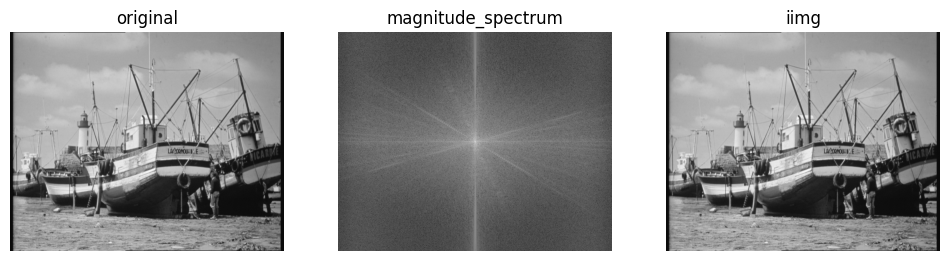

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('boat.bmp', cv2.IMREAD_GRAYSCALE)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift))

ishift = np.fft.ifftshift(fshift)
iimg = np.fft.ifft2(ishift)
iimg = np.abs(iimg)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img, cmap = 'gray')
plt.title('original')
plt.axis('off')

plt.subplot(132)
plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('magnitude_spectrum')
plt.axis('off')

plt.subplot(133)
plt.imshow(iimg, cmap = 'gray')
plt.title('iimg')
plt.axis('off')
plt.show()

#### 13.2 OpenCV 实现傅里叶变换
- 函数 `返回值 = cv2.dft(原始图像， 转换标识)` 实现傅里叶变换，其中
    - `原始图像` 需要先使用 `np.float32()` 转换成 `np.float32` 格式
    - `转换标识` 通常为 `cv2.DFT_COMPLEX_OUTPUT` 输出复数阵列
    - 返回结果与 `Numpy` 进行傅里叶变换的结果一致，但返回值是双通道，其中第1个通道是实数部分，第2个部分是虚数部分
- `dftshift = np.fft.fftishfit(dft)` 将频谱图像 dft 中的零频率分量移到频谱中心
- 函数 `返回值 = cv2.magnitude(参数1, 参数2)` 计算频谱信息的幅度，其中
    - 参数1/参数2：分别是浮点型 x 坐标值和 y 坐标值，对应实部和虚部，且 x 和 y 的 size 必须相同
    - 返回值是参数 1 和参数 2 的平方和的平方根
- `result = 20 * np.log(cv2.magnitude(实部, 虚部))` 将幅度值映射到灰度图像空间[0, 255]内，使其以灰度图像的形式显示
- 函数 `返回值 = cv2.idft(频域数据)` 实现傅里叶逆变换。如果移动了零频率分量的位置，要使用 `numpy.fft.iffshift()` 将零频率分量恢复到原来位置

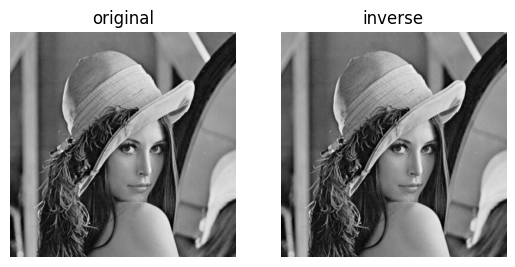

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('lena.bmp',cv2.IMREAD_GRAYSCALE)
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dftShift = np.fft.fftshift(dft)
ishift = np.fft.ifftshift(dftShift)
iImg = cv2.idft(ishift)
iImg = cv2.magnitude(iImg[:,:,0], iImg[:,:,1])
plt.subplot(121)
plt.imshow(img, cmap = 'gray')
plt.title('original')
plt.axis('off')
plt.subplot(122)
plt.imshow(iImg, cmap = 'gray')
plt.title('inverse')
plt.axis('off')
plt.show()

#### 13.3 滤波处理
- 高通滤波器衰减低频信号衰减而通过高频信号，将增强图像中的尖锐细节，但会导致图像的对比度降低
- 低通滤波器衰减高频信号衰减而通过低频信号，会使图像变模糊

rows = 512 cols = 512


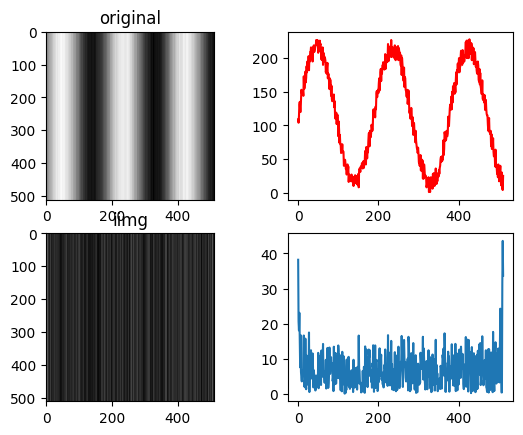

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('rand2.bmp',cv2.IMREAD_GRAYSCALE)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# 将傅里叶变换结果的中心区域（低频分量）设置为0，保留高频分量，实现高通滤波
rows, cols = img.shape
crow, ccol = int(rows/2) , int(cols/2)
fshift[crow-30:crow+30, ccol-30:ccol+30] = 0    
print("rows =", rows, "cols =", cols)

ishift = np.fft.ifftshift(fshift)
iimg = np.fft.ifft2(ishift)
iimg = np.abs(iimg)
plt.subplot(221)
plt.imshow(img, cmap = 'gray')
plt.title('original')
# plt.axis('off')
plt.subplot(223)
plt.imshow(iimg, cmap = 'gray')
plt.title('iimg')
# plt.axis('off')

# 可视化原始图像和滤波后图像在第 r 行的像素变化
r = 500
# print(img[r,:].shape)   # (512,)
plt.subplot(222)
plt.plot(img[r,:] ,color='r')
plt.subplot(224)
plt.plot(iimg[r,:])
plt.show()

rows = 512 cols = 512


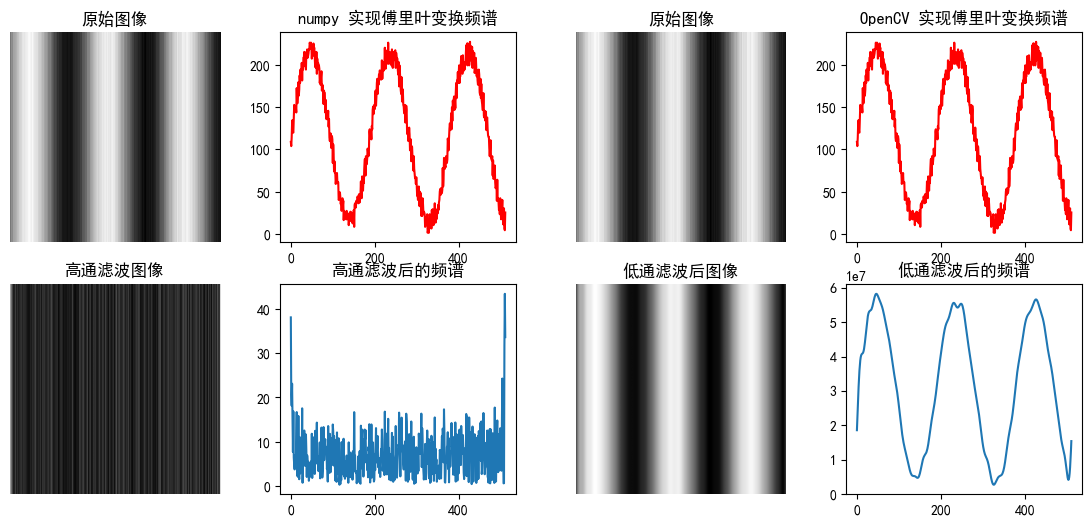

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "Arial"]    # 显示中文
plt.rcParams["axes.unicode_minus"] = False 

# ========= 高通滤波图像比较 ==============
img = cv2.imread('rand2.bmp',cv2.IMREAD_GRAYSCALE)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
# 将傅里叶变换结果的中心区域（低频分量）设置为0，保留高频分量，实现高通滤波
rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)
fshift[crow-30:crow+30, ccol-30:ccol+30] = 0
print("rows =", rows, "cols =", cols)   # 输出图像的行数和列数
ishift = np.fft.ifftshift(fshift)
iimg = np.fft.ifft2(ishift)
iimg = np.abs(iimg)

plt.figure(figsize=(14, 6))
plt.subplot(241)
plt.imshow(img, cmap = 'gray')
plt.title('原始图像')
plt.axis('off')
plt.subplot(245)
plt.imshow(iimg, cmap = 'gray')
plt.title('高通滤波图像')
plt.axis('off')
# 可视化图像在第 r 行的像素变化
r = 500
plt.subplot(242)
plt.plot(img[r,:] ,color='r')
plt.title('numpy 实现傅里叶变换频谱')
plt.subplot(246)
plt.plot(iimg[r,:])
plt.title('高通滤波后的频谱')


# ======= 低通滤波图像比较 ============
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dftshift = np.fft.fftshift(dft)
rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)
mask = np.zeros((rows, cols, 2), np.uint8)
# 通过掩膜保留傅里叶变换的中心区域（低频分量），实现低通滤波
mask[crow-30:crow+30, ccol-30:ccol+30] = 1
fshift = dftshift * mask
ishift = np.fft.ifftshift(fshift)
iImg = cv2.idft(ishift)
iImg= cv2.magnitude(iImg[:,:,0], iImg[:,:,1])

plt.subplot(243)
plt.imshow(img, cmap = 'gray')
plt.title('原始图像')
plt.axis('off')
plt.subplot(247)
plt.imshow(iImg, cmap = 'gray')
plt.title('低通滤波后图像')
plt.axis('off')
# 可视化图像在第 r 行的像素变化
r = 500
plt.subplot(244)
plt.plot(img[r,:] ,color='r')
plt.title('OpenCV 实现傅里叶变换频谱')
plt.subplot(248)
plt.plot(iImg[r,:])
plt.title('低通滤波后的频谱')
plt.show()

rows = 512 cols = 512


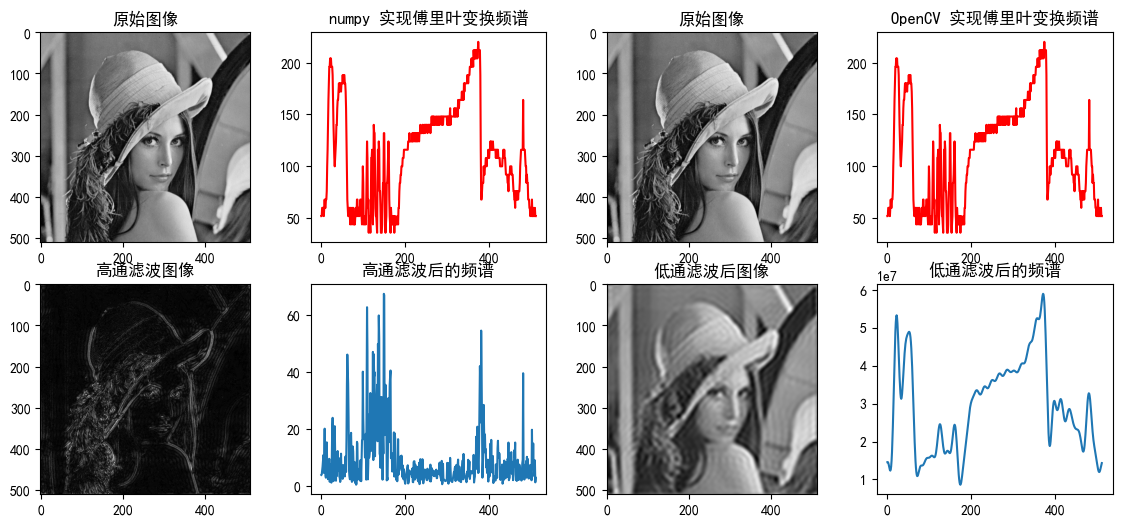

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "Arial"]    # 显示中文
plt.rcParams["axes.unicode_minus"] = False 

# ========= 高通滤波图像比较 ==============
img = cv2.imread('lena.bmp',cv2.IMREAD_GRAYSCALE)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
# 将傅里叶变换结果的中心区域（低频分量）设置为0，保留高频分量，实现高通滤波
rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)
fshift[crow-30:crow+30, ccol-30:ccol+30] = 0
print("rows =", rows, "cols =", cols)   # 输出图像的行数和列数
ishift = np.fft.ifftshift(fshift)
iimg = np.fft.ifft2(ishift)
iimg = np.abs(iimg)

plt.figure(figsize=(14, 6))
plt.subplot(241)
plt.imshow(img, cmap = 'gray')
plt.title('原始图像')
# plt.axis('off')
plt.subplot(245)
plt.imshow(iimg, cmap = 'gray')
plt.title('高通滤波图像')
# plt.axis('off')
# 可视化图像在第 r 行的像素变化
r = 500
plt.subplot(242)
plt.plot(img[r,:] ,color='r')
plt.title('numpy 实现傅里叶变换频谱')
plt.subplot(246)
plt.plot(iimg[r,:])
plt.title('高通滤波后的频谱')


# ======= 低通滤波图像比较 ============
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dftshift = np.fft.fftshift(dft)
rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)
mask = np.zeros((rows, cols, 2), np.uint8)
# 通过掩膜保留傅里叶变换的中心区域（低频分量），实现低通滤波
mask[crow-30:crow+30, ccol-30:ccol+30] = 1
fshift = dftshift * mask
ishift = np.fft.ifftshift(fshift)
iImg = cv2.idft(ishift)
iImg= cv2.magnitude(iImg[:,:,0], iImg[:,:,1])

plt.subplot(243)
plt.imshow(img, cmap = 'gray')
plt.title('原始图像')
# plt.axis('off')
plt.subplot(247)
plt.imshow(iImg, cmap = 'gray')
plt.title('低通滤波后图像')
# plt.axis('off')
# 可视化图像在第 r 行的像素变化
r = 500
plt.subplot(244)
plt.plot(img[r,:] ,color='r')
plt.title('OpenCV 实现傅里叶变换频谱')
plt.subplot(248)
plt.plot(iImg[r,:])
plt.title('低通滤波后的频谱')
plt.show()